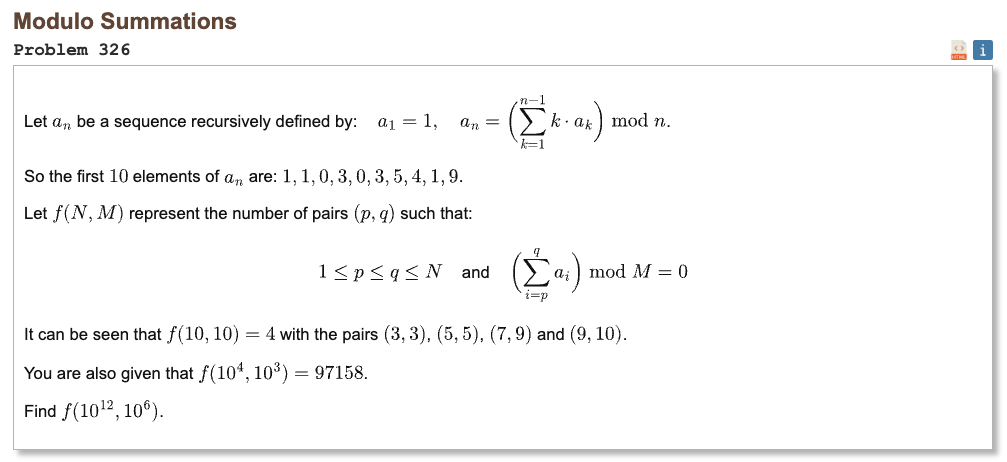

## Initial approach

* the prefix sums repeat modulo M with period 6 * M
* so we only need to generate one full period
* count how many times each prefix remainder appears in one period
* also count the prefix remainders in the leftover part
* two equal prefix remainders mean the subarray sum between them is divisible by M
* combine full-period counts and leftover counts
* sum the pair counts for all remainders

In [1]:
def f(N, M):
    period = 6 * M
    full_cycles = N // period
    remainder = N % period

    period_counts = [0] * M
    remainder_counts = [0] * M

    weighted_sum = 0
    prefix_sum = 0

    for i in range(period):
        period_counts[prefix_sum] += 1

        if i <= remainder:
            remainder_counts[prefix_sum] += 1

        n = i + 1

        if n == 1:
            a = 1
        else:
            a = weighted_sum % n

        weighted_sum += n * a
        prefix_sum = (prefix_sum + a) % M

    total = 0

    for r in range(M):
        count = full_cycles * period_counts[r] + remainder_counts[r]
        total += count * (count - 1) // 2

    return total

assert f(10, 10) == 4
assert f(10 ** 4, 10 ** 3) == 97158

In [2]:
%%time
result = f(10 ** 12, 10 ** 6)
print("Result:", result)

Result: 1966666166408794329
CPU times: user 944 ms, sys: 7.1 ms, total: 951 ms
Wall time: 950 ms
